In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('Salary_Data.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [3]:

df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


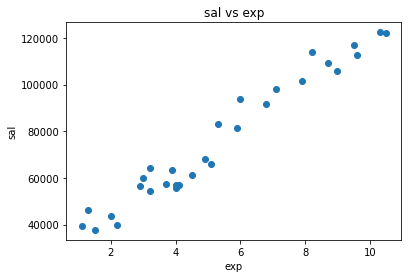

In [5]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df['YearsExperience'], df['Salary']);

In [6]:
x = df[['YearsExperience']]
y = df['Salary']

In [7]:
y;

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state= 0,
                                                    test_size = 0.25)

In [9]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((22, 1), (22,), (8, 1), (8,))

In [10]:

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

LinearRegression()

In [11]:
lr.coef_

array([9379.71049195])

In [12]:
lr.intercept_

26986.691316737248

In [13]:
y_pred = lr.predict(x_test)

In [14]:

pd.DataFrame({'actual': y_test,
              'pred': y_pred})

,actual,pred
2,37731.0,41056.257055
28,122391.0,123597.709384
13,57081.0,65443.504334
10,63218.0,63567.562235
26,116969.0,116093.940990
24,109431.0,108590.172597
27,112635.0,117031.912039
11,55794.0,64505.533285


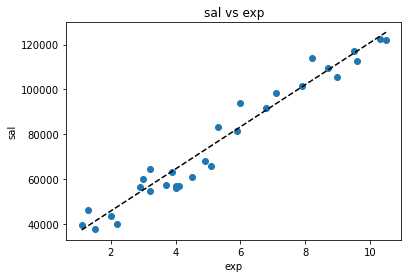

In [15]:
plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df['YearsExperience'], df['Salary']);
plt.plot(x, lr.predict(x), color = 'black', ls = '--');

In [16]:

from sklearn.metrics import  mean_absolute_error


In [17]:

mean_absolute_error(y_test, y_pred)

3508.5455930660555

In [18]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9779208335417602

In [19]:
##polynomial reg

In [20]:
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [21]:

from sklearn.preprocessing import PolynomialFeatures

In [22]:
poly = PolynomialFeatures(degree= 4)


In [23]:
x_poly = poly.fit_transform(x)


In [24]:
x_poly


array([[1.00000000e+00, 1.10000000e+00, 1.21000000e+00, 1.33100000e+00,
        1.46410000e+00],
       [1.00000000e+00, 1.30000000e+00, 1.69000000e+00, 2.19700000e+00,
        2.85610000e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01],
       [1.00000000e+00, 2.20000000e+00, 4.84000000e+00, 1.06480000e+01,
        2.34256000e+01],
       [1.00000000e+00, 2.90000000e+00, 8.41000000e+00, 2.43890000e+01,
        7.07281000e+01],
       [1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01,
        8.10000000e+01],
       [1.00000000e+00, 3.20000000e+00, 1.02400000e+01, 3.27680000e+01,
        1.04857600e+02],
       [1.00000000e+00, 3.20000000e+00, 1.02400000e+01, 3.27680000e+01,
        1.04857600e+02],
       [1.00000000e+00, 3.70000000e+00, 1.36900000e+01, 5.06530000e+01,
        1.87416100e+02],
       [1.00000000e+00, 3.9000

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x_poly, y,
                                                    random_state=0)
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [26]:

y_pred = lr.predict(x_test)

In [27]:

r2_score(y_test, y_pred)

0.9820816859990569

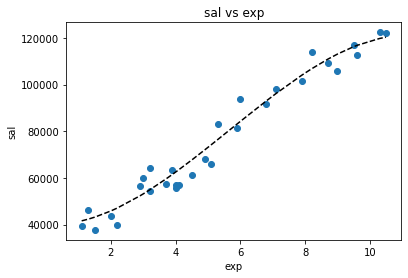

In [28]:

plt.title("sal vs exp")
plt.xlabel("exp")
plt.ylabel("sal")
plt.scatter(df['YearsExperience'], df['Salary']);
plt.plot(x, lr.predict(x_poly), color = 'black', ls = '--');